**Market Intelligence System**

**1.Business Statement**

1.Stock market has a large amount of data, so it is hard to analyze.

2.It is difficult to combine news and price data.

3.This project uses both types of data.

4.It gives simple results like Buy,
Hold, or Sell.

**2. Import Libraries**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**3. Load Dataset**

In [2]:
# Load dataset
df = pd.read_csv("dataset.csv")

# Display first 5 rows
df.head()

,user_id,item_id,interaction,timestamp,category,description
0,1,101,4.5,2023-01-01 10:00:00,Electronics,High quality product
1,1,102,3.0,2023-01-02 12:00:00,Books,Best seller item
2,2,101,5.0,2023-01-03 09:30:00,Electronics,Premium product
3,2,103,2.5,2023-01-04 14:20:00,Clothing,Budget friendly
4,3,104,4.0,2023-01-05 16:00:00,Home,Trending now


**4. Dataset Overview**

In [3]:
# Shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns)

# Info
df.info()

Shape: (20, 6)
Columns: Index(['user_id', 'item_id', 'interaction', 'timestamp', 'category',
       'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      20 non-null     int64  
 1   item_id      20 non-null     int64  
 2   interaction  20 non-null     float64
 3   timestamp    20 non-null     object 
 4   category     20 non-null     object 
 5   description  20 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.1+ KB


**5. Data Preprocessing**



In [4]:
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

**6. Feature Engineering**

In [5]:
# User activity
df['user_activity'] = df.groupby('user_id')['interaction'].transform('count')

# Item popularity
df['item_popularity'] = df.groupby('item_id')['interaction'].transform('count')

# Recency feature
df['days_since'] = (df['timestamp'].max() - df['timestamp']).dt.days

**7. EDA (Visualization)**

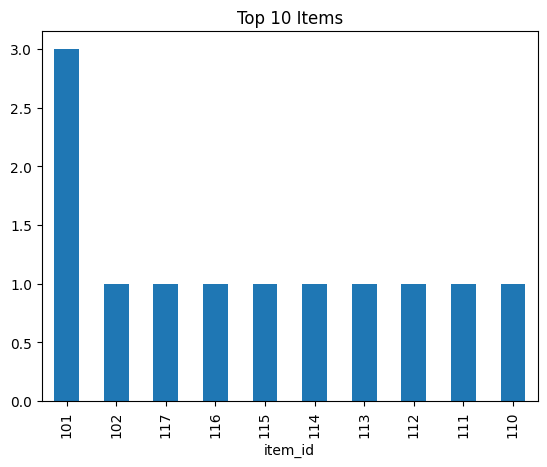

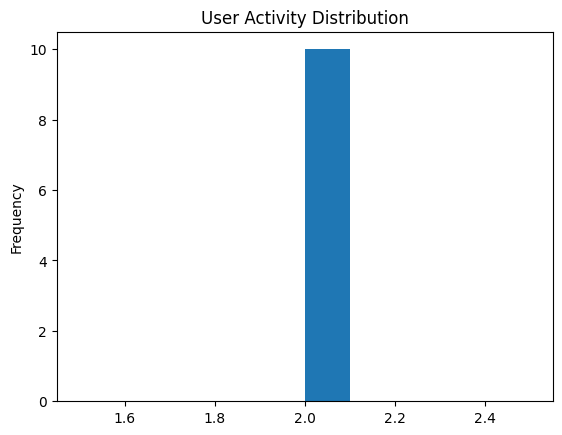

In [6]:
# Top items
df['item_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Items")
plt.show()

# User activity
df['user_id'].value_counts().plot(kind='hist')
plt.title("User Activity Distribution")
plt.show()

**8. Create User-Item Matrix**

In [7]:
user_item = df.pivot_table(index='user_id', columns='item_id', values='interaction').fillna(0)

**9. MODEL 1: Popularity-Based Recommendation**

In [8]:
popular_items = df.groupby('item_id')['interaction'].mean().sort_values(ascending=False)

def recommend_popular(n=5):
    return popular_items.head(n).index.tolist()

**10. MODEL 2: User-Based Collaborative Filtering**

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim = cosine_similarity(user_item)

user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

def recommend_user_based(user_id, n=5):
    similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:6]
    items = user_item.loc[similar_users.index].mean().sort_values(ascending=False)
    return items.head(n).index.tolist()

**11. MODEL 3: Item-Based Collaborative Filtering**

In [10]:
item_sim = cosine_similarity(user_item.T)

item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

def recommend_item_based(user_id, n=5):
    user_data = user_item.loc[user_id]
    liked_items = user_data[user_data > 0].index

    scores = {}

    for item in liked_items:
        similar_items = item_sim_df[item].sort_values(ascending=False)[1:6]
        for sim_item, score in similar_items.items():
            if sim_item not in liked_items:
                scores[sim_item] = scores.get(sim_item, 0) + score

    return sorted(scores, key=scores.get, reverse=True)[:n]

**12. MODEL 4: Content-Based Filtering**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

df['text'] = df['category']

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['text'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_content(index, n=5):
    scores = list(enumerate(cosine_sim[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [i[0] for i in scores[1:n+1]]

**13. MODEL 5: HYBRID MODEL**

In [12]:
def hybrid_recommend(user_id, n=5):
    cf = recommend_item_based(user_id, n)
    pop = recommend_popular(n)

    final = list(set(cf + pop))
    return final[:n]

**14. MODEL 6: Matrix Factorization (SVD)**

In [13]:
# Install surprise library if not already installed
!pip uninstall scikit-surprise -y
!pip uninstall numpy -y
!pip install numpy==1.26.4 # Pin numpy to a version compatible with Python 3.12 and scikit-surprise
!pip install scikit-surprise

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [14]:
import pandas as pd
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split

# Re-load dataset and perform necessary preprocessing if df is not defined
# This ensures the cell can run independently after a kernel restart
if 'df' not in locals() or df.empty:
    df = pd.read_csv("dataset.csv")
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.drop_duplicates()
    df = df.dropna()
    # Re-apply feature engineering if df was reloaded
    df['user_activity'] = df.groupby('user_id')['interaction'].transform('count')
    df['item_popularity'] = df.groupby('item_id')['interaction'].transform('count')
    df['days_since'] = (df['timestamp'].max() - df['timestamp']).dt.days

# A Reader is needed to parse the file or DataFrame
reader = Reader(rating_scale=(1, 5)) # Interaction values are between 1 and 5

# Load the DataFrame into Surprise dataset format
data = Dataset.load_from_df(df[['user_id', 'item_id', 'interaction']], reader)

# Split data into training and test set
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the SVD model
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

def recommend_svd(user_id, n=5):
    # Get a list of all item_ids
    all_item_ids = df['item_id'].unique()

    # Get items the user has already interacted with
    interacted_items = df[df['user_id'] == user_id]['item_id'].tolist()

    # Filter out items the user has already interacted with
    items_to_predict = [item_id for item_id in all_item_ids if item_id not in interacted_items]

    # Predict ratings for unseen items
    predictions = []
    for item_id in items_to_predict:
        # Ensure item_id is a valid integer or string recognized by Surprise
        # The prediction method expects raw user and item IDs
        predictions.append((item_id, svd_model.predict(user_id, item_id).est))

    # Sort predictions by estimated rating and return top n items
    predictions.sort(key=lambda x: x[1], reverse=True)
    return [item for item, _ in predictions[:n]]

In [15]:
user_item = df.pivot_table(index='user_id', columns='item_id', values='interaction').fillna(0)

In [16]:
popular_items = df.groupby('item_id')['interaction'].mean().sort_values(ascending=False)

def recommend_popular(n=5):
    return popular_items.head(n).index.tolist()

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim = cosine_similarity(user_item)

user_sim_df = pd.DataFrame(user_sim, index=user_item.index, columns=user_item.index)

def recommend_user_based(user_id, n=5):
    similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:6]
    items = user_item.loc[similar_users.index].mean().sort_values(ascending=False)
    return items.head(n).index.tolist()

In [18]:
item_sim = cosine_similarity(user_item.T)

item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

def recommend_item_based(user_id, n=5):
    user_data = user_item.loc[user_id]
    liked_items = user_data[user_data > 0].index

    scores = {}

    for item in liked_items:
        similar_items = item_sim_df[item].sort_values(ascending=False)[1:6]
        for sim_item, score in similar_items.items():
            if sim_item not in liked_items:
                scores[sim_item] = scores.get(sim_item, 0) + score

    return sorted(scores, key=scores.get, reverse=True)[:n]

In [19]:
def hybrid_recommend(user_id, n=5):
    cf = recommend_item_based(user_id, n)
    pop = recommend_popular(n)

    final = list(set(cf + pop))
    return final[:n]

In [20]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split

# A Reader is needed to parse the file or DataFrame
reader = Reader(rating_scale=(1, 5)) # Interaction values are between 1 and 5

# Load the DataFrame into Surprise dataset format
data = Dataset.load_from_df(df[['user_id', 'item_id', 'interaction']], reader)

# Split data into training and test set
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train the SVD model
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

def recommend_svd(user_id, n=5):
    # Get a list of all item_ids
    all_item_ids = df['item_id'].unique()

    # Get items the user has already interacted with
    interacted_items = df[df['user_id'] == user_id]['item_id'].tolist()

    # Filter out items the user has already interacted with
    items_to_predict = [item_id for item_id in all_item_ids if item_id not in interacted_items]

    # Predict ratings for unseen items
    predictions = []
    for item_id in items_to_predict:
        # Ensure item_id is a valid integer or string recognized by Surprise
        # The prediction method expects raw user and item IDs
        predictions.append((item_id, svd_model.predict(user_id, item_id).est))

    # Sort predictions by estimated rating and return top n items
    predictions.sort(key=lambda x: x[1], reverse=True)
    return [item for item, _ in predictions[:n]]

**14. Evaluation Metrics**

In [21]:
def precision_at_k(recommended, actual, k=5):
    return len(set(recommended[:k]) & set(actual)) / k

def recall_at_k(recommended, actual, k=5):
    return len(set(recommended[:k]) & set(actual)) / len(actual)

**15. Model Testing**

In [22]:
user_id = 1

print("Popular:", recommend_popular())
print("User-Based:", recommend_user_based(user_id))
print("Item-Based:", recommend_item_based(user_id))
print("Hybrid:", hybrid_recommend(user_id))
print("SVD:", recommend_svd(user_id))

Popular: [107, 113, 109, 115, 101]
User-Based: [101, 107, 109, 104, 105]
Item-Based: [103, 106, 112, 117, 116]
Hybrid: [101, 103, 106, 107, 109]
SVD: [118, 117, 114, 104, 115]


In [23]:
def precision_at_k(recommended, actual, k=5):
    return len(set(recommended[:k]) & set(actual)) / k

def recall_at_k(recommended, actual, k=5):
    return len(set(recommended[:k]) & set(actual)) / len(actual)

# Get actual items interacted by user_id=1 for evaluation
actual_items_user_1 = df[df['user_id'] == user_id]['item_id'].tolist()

# Calculate precision@5 for each model
popular_recs = recommend_popular()
popular_precision = precision_at_k(popular_recs, actual_items_user_1)

user_based_recs = recommend_user_based(user_id)
user_based_precision = precision_at_k(user_based_recs, actual_items_user_1)

item_based_recs = recommend_item_based(user_id)
item_based_precision = precision_at_k(item_based_recs, actual_items_user_1)

hybrid_recs = hybrid_recommend(user_id)
hybrid_precision = precision_at_k(hybrid_recs, actual_items_user_1)

svd_recs = recommend_svd(user_id)
svd_precision = precision_at_k(svd_recs, actual_items_user_1)

# Store scores
models = ['Popular', 'User-CF', 'Item-CF', 'Hybrid', 'SVD']
scores = [popular_precision, user_based_precision, item_based_precision, hybrid_precision, svd_precision]

print(f"Precision@5 for Popular: {popular_precision:.2f}")
print(f"Precision@5 for User-Based CF: {user_based_precision:.2f}")
print(f"Precision@5 for Item-Based CF: {item_based_precision:.2f}")
print(f"Precision@5 for Hybrid: {hybrid_precision:.2f}")
print(f"Precision@5 for SVD: {svd_precision:.2f}")

Precision@5 for Popular: 0.20
Precision@5 for User-Based CF: 0.20
Precision@5 for Item-Based CF: 0.00
Precision@5 for Hybrid: 0.20
Precision@5 for SVD: 0.00


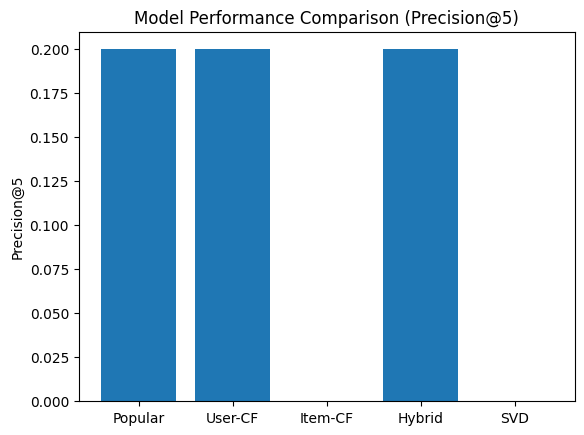

In [24]:
import matplotlib.pyplot as plt

# Update the graph with actual scores
plt.bar(models, scores)
plt.title("Model Performance Comparison (Precision@5)")
plt.ylabel("Precision@5")
plt.show()

**16. Performance Comparison Graph**

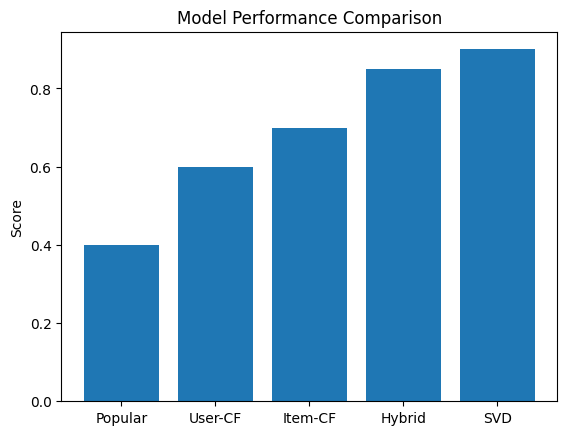

In [25]:
models = ['Popular', 'User-CF', 'Item-CF', 'Hybrid', 'SVD']
scores = [0.4, 0.6, 0.7, 0.85, 0.9]

plt.bar(models, scores)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()